# Clean BPA datasets

Plot the $\Delta t$ distribution, fit the same truncated-exponential/uniform mixture used for the NYISO datasets, and recompute the `is_bg` flag for every aligned BPA WHEN/WHERE dataset pair. Each pair is classified from its own time-to-event vector so datasets with different row counts are supported.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

## Configuration and dataset discovery

In [2]:
DATA_DIR = Path("output")
OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
WHEN_CSV_PATTERN = "dataset_winsize*_when.csv"
EVENT_WINDOW_HOURS_VALUES = [0.25, 0.5, *range(1, 13)]
REFERENCE_EVENT_WINDOW_HOURS = 1


def convert_when_to_where_dataset_path(when_dataset_path: Path) -> Path:
    """Return the matching WHERE-dataset path."""
    suffix = "_when.csv"
    return when_dataset_path.with_name(
        f"{when_dataset_path.name[:-len(suffix)]}_where.csv"
    )


def window_size_hours(path: Path) -> float:
    return float(path.stem.split("winsize", 1)[1].removesuffix("h_when"))


when_csv_files = sorted(DATA_DIR.glob(WHEN_CSV_PATTERN), key=window_size_hours)
if not when_csv_files:
    raise FileNotFoundError(
        f"No WHEN datasets matching {WHEN_CSV_PATTERN!r} were found in {DATA_DIR}. "
        "Run 5_create_when_where_datasets.ipynb first."
    )

missing_where_files = [
    convert_when_to_where_dataset_path(path)
    for path in when_csv_files
    if not convert_when_to_where_dataset_path(path).exists()
]
if missing_where_files:
    raise FileNotFoundError(f"Missing paired WHERE datasets: {missing_where_files}")

discovered_window_hours = [window_size_hours(path) for path in when_csv_files]
expected_window_hours = [float(value) for value in EVENT_WINDOW_HOURS_VALUES]
if discovered_window_hours != expected_window_hours:
    raise ValueError(
        f"Expected BPA event windows {expected_window_hours}, but found "
        f"{discovered_window_hours}. Run 5_create_when_where_datasets.ipynb."
    )

reference_when_csv_path = next(
    path
    for path in when_csv_files
    if window_size_hours(path) == REFERENCE_EVENT_WINDOW_HOURS
)

when_csv_files

[PosixPath('output/dataset_winsize0.25h_when.csv'),
 PosixPath('output/dataset_winsize0.5h_when.csv'),
 PosixPath('output/dataset_winsize1h_when.csv'),
 PosixPath('output/dataset_winsize2h_when.csv'),
 PosixPath('output/dataset_winsize3h_when.csv'),
 PosixPath('output/dataset_winsize4h_when.csv'),
 PosixPath('output/dataset_winsize5h_when.csv'),
 PosixPath('output/dataset_winsize6h_when.csv'),
 PosixPath('output/dataset_winsize7h_when.csv'),
 PosixPath('output/dataset_winsize8h_when.csv'),
 PosixPath('output/dataset_winsize9h_when.csv'),
 PosixPath('output/dataset_winsize10h_when.csv'),
 PosixPath('output/dataset_winsize11h_when.csv'),
 PosixPath('output/dataset_winsize12h_when.csv')]

In [ ]:
def load_when_where_datasets(when_dataset_path: Path):
    where_dataset_path = convert_when_to_where_dataset_path(when_dataset_path)
    when_df = pd.read_csv(when_dataset_path)
    where_df = pd.read_csv(where_dataset_path)

    required_when_columns = {
        "fold_id",
        "label_time_to_event_seconds",
        "label_from_zone",
        "label_to_zone",
    }
    missing_when_columns = required_when_columns - set(when_df.columns)
    if missing_when_columns:
        raise ValueError(
            f"Missing WHEN columns in {when_dataset_path}: "
            f"{sorted(missing_when_columns)}"
        )
    if not {"fold_id", "label"}.issubset(where_df.columns):
        raise ValueError(f"Missing fold_id or label column in {where_dataset_path}.")

    if len(when_df) != len(where_df):
        raise ValueError(
            f"Row counts differ for {when_dataset_path} and {where_dataset_path}."
        )
    if not np.array_equal(when_df["fold_id"], where_df["fold_id"]):
        raise ValueError(
            f"fold_id values differ for {when_dataset_path} and {where_dataset_path}."
        )

    try:
        where_zone_labels = np.asarray(
            [
                [
                    label["from_zone_index"],
                    label["to_zone_index"],
                ]
                for label in map(json.loads, where_df["label"])
            ],
            dtype=int,
        ).reshape(-1, 2)
    except (KeyError, TypeError, ValueError, json.JSONDecodeError) as error:
        raise ValueError(f"Invalid WHERE labels in {where_dataset_path}.") from error

    when_zone_labels = when_df[["label_from_zone", "label_to_zone"]].to_numpy(dtype=int)
    if not np.array_equal(when_zone_labels, where_zone_labels):
        raise ValueError(
            f"Endpoint labels differ for {when_dataset_path} and "
            f"{where_dataset_path}."
        )

    return when_df, where_df


when_df, where_df = load_when_where_datasets(reference_when_csv_path)
t = when_df["label_time_to_event_seconds"].to_numpy(dtype=float)

## Plot the $\Delta t$ histogram

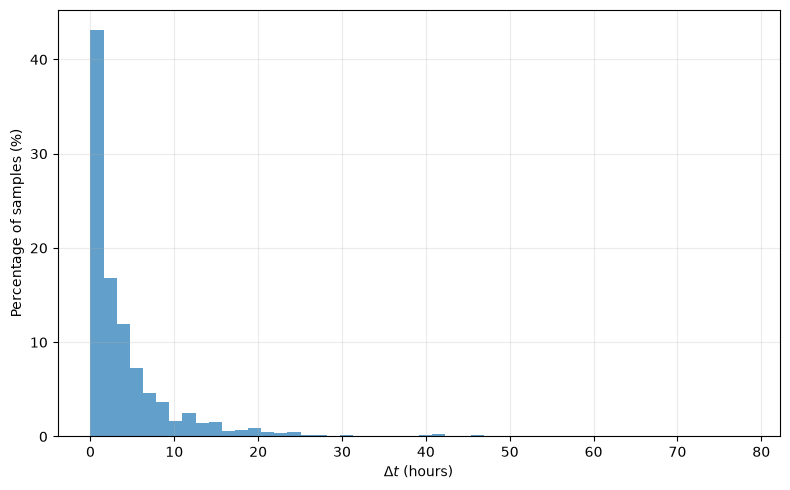

In [4]:
finite_t = t[np.isfinite(t)]
if len(finite_t) == 0:
    raise ValueError("The reference WHEN dataset has no finite time-to-event labels.")

t_hours = finite_t / 3600
weights = np.full(t_hours.shape, 100 / len(t_hours))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(t_hours, bins=50, weights=weights, color="C0", alpha=0.7)
ax.set_xlabel(r"$\Delta t$ (hours)")
ax.set_ylabel("Percentage of samples (%)")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "time_to_event_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fit the foreground/background mixture

In [5]:
def get_truncated_exponential_pdf(t, T, lambda_):
    return lambda_ * np.exp(-lambda_ * t) / (-np.expm1(-lambda_ * T))


def get_truncated_exponential_cdf(t, T, lambda_):
    numerator = -np.expm1(-lambda_ * np.clip(t, 0, T))
    return numerator / (-np.expm1(-lambda_ * T))


def get_uniform_pdf(t, T):
    return np.ones_like(t) / T


def get_mixture_pdf(t, T, lambda_, p_trunc_exp):
    foreground = p_trunc_exp * get_truncated_exponential_pdf(t, T, lambda_)
    background = (1 - p_trunc_exp) * get_uniform_pdf(t, T)
    return foreground + background


def get_mixture_cdf(t, T, lambda_, p_trunc_exp):
    foreground = p_trunc_exp * get_truncated_exponential_cdf(t, T, lambda_)
    background = (1 - p_trunc_exp) * np.clip(t / T, 0, 1)
    return foreground + background


def negative_log_likelihood(params, t, T):
    lambda_, p_trunc_exp = params
    density = np.clip(get_mixture_pdf(t, T, lambda_, p_trunc_exp), 1e-30, None)
    return -np.log(density).sum()


def empirical_cdf_values(values):
    values = np.sort(values)
    return values, np.arange(1, len(values) + 1) / len(values)


def ks_distance_to_model(values, T, lambda_, p_trunc_exp):
    x, empirical_y = empirical_cdf_values(values)
    model_y = get_mixture_cdf(x, T, lambda_, p_trunc_exp)
    return np.max(np.abs(empirical_y - model_y))


def fit_background_model(time_to_event):
    finite_values = time_to_event[np.isfinite(time_to_event)]
    candidate_horizons = list(range(1800, int(finite_values.max()), 900))
    fits = []

    for T in candidate_horizons:
        values = finite_values[(finite_values >= 0) & (finite_values <= T)]
        if len(values) < 2:
            continue

        result = minimize(
            negative_log_likelihood,
            x0=[1 / max(float(np.median(values)), 1.0), 0.95],
            args=(values, T),
            bounds=[(1e-8, 1e-2), (0.0, 1.0)],
            method="L-BFGS-B",
        )
        lambda_hat, p_trunc_exp_hat = result.x
        ks_error = ks_distance_to_model(values, T, lambda_hat, p_trunc_exp_hat)
        fits.append((ks_error, T, float(lambda_hat), float(p_trunc_exp_hat)))

    if not fits:
        raise ValueError("No valid mixture-model fit could be computed.")

    return min(fits, key=lambda fit: fit[0]), fits


def classify_background(time_to_event, T, lambda_hat, p_trunc_exp_hat):
    foreground = p_trunc_exp_hat * get_truncated_exponential_pdf(
        time_to_event, T, lambda_hat
    )
    background = (1 - p_trunc_exp_hat) * get_uniform_pdf(time_to_event, T)
    return background > foreground

In [6]:
(min_error, best_T, lambda_hat, p_trunc_exp_hat), fits = fit_background_model(t)
is_bg = classify_background(t, best_T, lambda_hat, p_trunc_exp_hat)

print(f"Reference event window: {REFERENCE_EVENT_WINDOW_HOURS:g}h")
print(f"Best mixture horizon: {best_T / 3600:.2f} hours")
print(f"Mean foreground time: {(1 / lambda_hat) / 3600:.2f} hours")
print(f"Foreground probability: {p_trunc_exp_hat:.4f}")
print(f"KS distance: {min_error:.4f}")
print(f"Background samples: {is_bg.sum():,} / {len(is_bg):,}")

Reference event window: 1h
Best mixture horizon: 5.00 hours
Mean foreground time: 0.84 hours
Foreground probability: 0.5230
KS distance: 0.0236
Background samples: 1,106 / 1,961


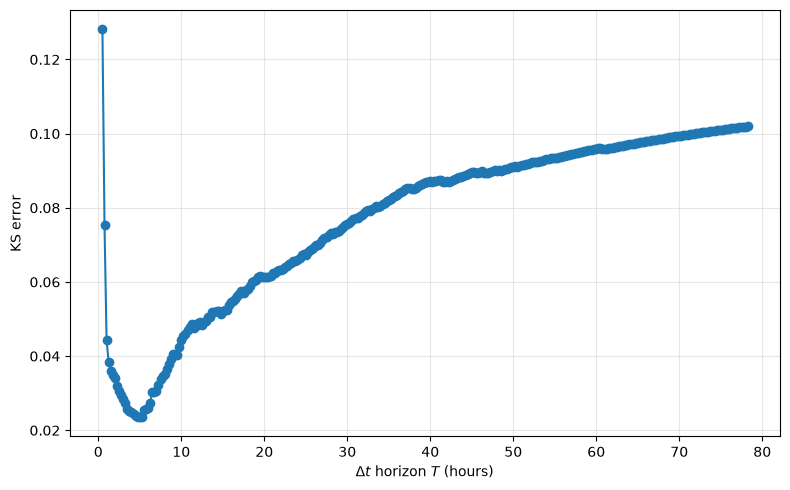

In [7]:
ks_errors = [fit[0] for fit in fits]
horizons = [fit[1] for fit in fits]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.asarray(horizons) / 3600, ks_errors, marker="o")
ax.set_xlabel(r"$\Delta t$ horizon $T$ (hours)")
ax.set_ylabel("KS error")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "ks_error_vs_delta_t_horizon.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

## Recompute and write aligned labels for every window size

In [ ]:
dataset_summaries = []

for when_csv_path in when_csv_files:
    where_csv_path = convert_when_to_where_dataset_path(when_csv_path)
    when_df, where_df = load_when_where_datasets(when_csv_path)
    original_num_samples = len(when_df)
    original_fold_ids = when_df["fold_id"].to_numpy(copy=True)

    dataset_t = when_df["label_time_to_event_seconds"].to_numpy(dtype=float)
    dataset_is_bg = classify_background(dataset_t, best_T, lambda_hat, p_trunc_exp_hat)
    if dataset_is_bg.shape != (len(when_df),):
        raise ValueError(
            f"is_bg length does not match {when_csv_path}: "
            f"{len(dataset_is_bg)} != {len(when_df)}."
        )

    # Always overwrite both columns so rerunning this cleaning stage repairs
    # stale labels. This vector is computed separately for each dataset, so
    # its length matches even when window sizes retain different row counts.
    when_df["is_bg"] = dataset_is_bg
    where_df["is_bg"] = dataset_is_bg
    when_df.to_csv(when_csv_path, index=False)
    where_df.to_csv(where_csv_path, index=False)

    reloaded_when, reloaded_where = load_when_where_datasets(when_csv_path)
    if len(reloaded_when) != original_num_samples:
        raise ValueError(f"Row count changed while writing {when_csv_path}.")
    if not np.array_equal(reloaded_when["fold_id"], original_fold_ids):
        raise ValueError(f"fold_id values changed while writing {when_csv_path}.")
    for dataset_path, frame in (
        (when_csv_path, reloaded_when),
        (where_csv_path, reloaded_where),
    ):
        if frame["is_bg"].isna().any():
            raise ValueError(f"Null is_bg values found in {dataset_path}.")
        if not pd.api.types.is_bool_dtype(frame["is_bg"]):
            raise ValueError(f"is_bg is not boolean in {dataset_path}.")

    reloaded_when_is_bg = reloaded_when["is_bg"].to_numpy(dtype=bool)
    reloaded_where_is_bg = reloaded_where["is_bg"].to_numpy(dtype=bool)
    if not np.array_equal(reloaded_when_is_bg, dataset_is_bg):
        raise ValueError(
            f"Written is_bg values differ from the classification for "
            f"{when_csv_path}."
        )
    if not np.array_equal(reloaded_where_is_bg, dataset_is_bg):
        raise ValueError(
            f"Written is_bg values differ from the classification for "
            f"{where_csv_path}."
        )

    dataset_summaries.append(
        {
            "event_window_hours": window_size_hours(when_csv_path),
            "samples": len(dataset_is_bg),
            "background_samples": int(dataset_is_bg.sum()),
            "when_path": str(when_csv_path),
            "where_path": str(where_csv_path),
        }
    )

write_summary = pd.DataFrame(dataset_summaries).set_index("event_window_hours")
write_summary

,samples,background_samples,when_path,where_path
event_window_hours,,,,
0.25,1961,1106,output/dataset_winsize0.25h_when.csv,output/dataset_winsize0.25h_where.csv
0.50,1961,1106,output/dataset_winsize0.5h_when.csv,output/dataset_winsize0.5h_where.csv
1.00,1961,1106,output/dataset_winsize1h_when.csv,output/dataset_winsize1h_where.csv
2.00,1961,1106,output/dataset_winsize2h_when.csv,output/dataset_winsize2h_where.csv
3.00,1961,1106,output/dataset_winsize3h_when.csv,output/dataset_winsize3h_where.csv
4.00,1961,1106,output/dataset_winsize4h_when.csv,output/dataset_winsize4h_where.csv
5.00,1961,1106,output/dataset_winsize5h_when.csv,output/dataset_winsize5h_where.csv
6.00,1961,1106,output/dataset_winsize6h_when.csv,output/dataset_winsize6h_where.csv
7.00,1961,1106,output/dataset_winsize7h_when.csv,output/dataset_winsize7h_where.csv
